In [4]:
#Step 1 — Install/import libraries
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from mlxtend.frequent_patterns import apriori, association_rules
from dash import Dash, dcc, html, Input, Output

In [5]:
#Step 2 — Load your Superstore data
df = pd.read_csv("../data/Supermart Grocery Sales.csv")
print(df.head())

  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  South   2355      0.26  918.45  Tamil Nadu  


In [6]:
print(df.shape)

(9994, 11)


In [7]:
print(df.columns)

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='str')


In [8]:
df.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB
None


In [9]:
df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [10]:
#Sales vs Profit by Category-Do categories with high sales also generate high profit?
category_performance = (
    df.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

fig = px.bar(
    category_performance,
    x="Category",
    y=["Sales", "Profit"],
    barmode="group",
    title="Sales vs Profit by Category"
)

fig.show()

In [ ]:
#Instead of looking only at sales, I compared sales and profit together to see whether strong revenue also translated into profitability

In [11]:
# Profit Margin by Category
# Calculate category-level sales and profit
category_margin = (
    df.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

# Compute profit margin percentage
category_margin["Profit Margin"] = (
    category_margin["Profit"] /
    category_margin["Sales"] * 100
)

# Sort by margin
category_margin = category_margin.sort_values(
    "Profit Margin",
    ascending=False
)

import plotly.express as px

fig = px.scatter(
    category_margin,
    x="Profit Margin",
    y="Category",
    color="Profit Margin",
    color_continuous_scale="Blues",
    size=[14]*len(category_margin),
    title="Profit Margin by Category (Ranked Dot Plot)",
    text=category_margin["Profit Margin"].round(1).astype(str) + "%"
)

fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Profit Margin: %{x:.1f}%<extra></extra>"
)

fig.update_layout(
    xaxis=dict(range=[24.0, category_margin["Profit Margin"].max() + 0.5])
)

fig.show()

In [12]:
#I calculated profit margin to compare profitability efficiency rather than just total profit.

In [ ]:
# Monthly Sales AND Profit-Do sales and profit move together over time?
import plotly.graph_objects as go

fig = go.Figure()

# Sales line
fig.add_trace(go.Scatter(
    x=monthly_performance["Order Date"],
    y=monthly_performance["Sales"],
    name="Sales",
    mode="lines+markers",
    line=dict(color="blue")
))

# Profit line (secondary axis)
fig.add_trace(go.Scatter(
    x=monthly_performance["Order Date"],
    y=monthly_performance["Profit"],
    name="Profit",
    mode="lines+markers",
    line=dict(color="red"),
    yaxis="y2"
))

fig.update_layout(
    title="Monthly Sales and Profit Trend (Dual Axis)",
    xaxis=dict(title="Month"),
    yaxis=dict(title="Sales"),
    yaxis2=dict(
        title="Profit",
        overlaying="y",
        side="right",
        position=0.98   # valid range, prevents overlap
    ),
    margin=dict(r=80),
    plot_bgcolor="white"
)

fig.show()

In [14]:
# Regional Performance - Which regions contribute the most sales and profit?
#This allows us to compare performance across regions and identify differences between revenue and profitability
region_performance = (
    df.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

import plotly.express as px

fig = px.treemap(
    region_performance,
    path=["Region"],
    values="Sales",
    color="Profit",
    color_continuous_scale="RdBu",
    title="Regional Sales & Profit (Treemap)"
)

# Clean hover box
fig.update_traces(
    hovertemplate=
    '<b>Region:</b> %{label}<br>' +
    '<b>Sales:</b> %{value}<br>' +
    '<b>Profit:</b> %{color}<br>' +
    '<extra></extra>'   # removes extra fields
)

fig.update_layout(
    plot_bgcolor="white",
    margin=dict(t=50, l=20, r=20, b=20)
)

fig.show()


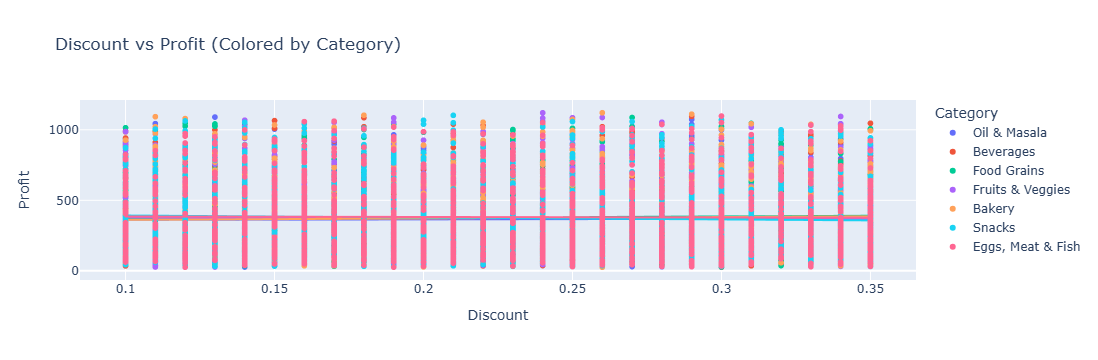

In [115]:
#Does discount have a relationship with profit?
fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    color="Category",
    trendline="ols",
    hover_data=["Customer Name", "Sub Category"],
    title="Discount vs Profit (Colored by Category)"
)

fig.show()

In [ ]:
fig = px.scatter(
    df,
    x="Discount",
    y="Profit",
    color="Region",
    trendline="ols",
    title="Discount vs Profit (Colored by Region)"
)

fig.show()

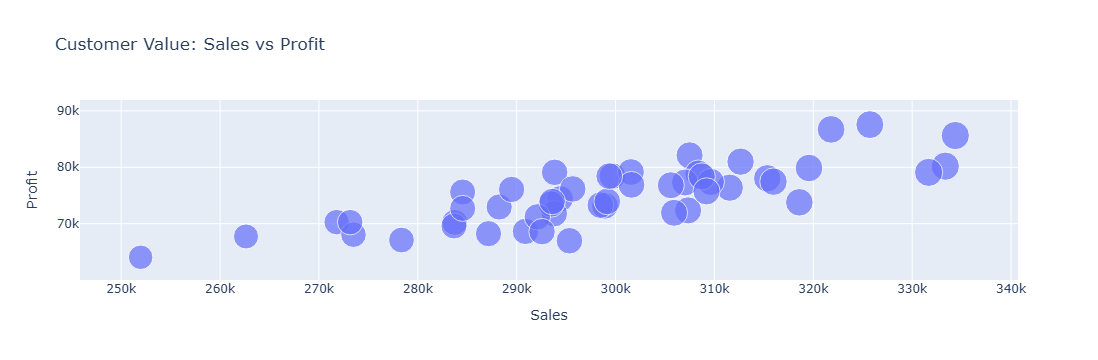

In [71]:
#Customer Value Matrix- Customer Sales vs Customer Profit
#Which customers generate both high sales and high profit?
customer_value = (
    df.groupby("Customer Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

fig = px.scatter(
    customer_value,
    x="Sales",
    y="Profit",
    hover_name="Customer Name",
    size="Sales",
    title="Customer Value: Sales vs Profit"
)

fig.show()

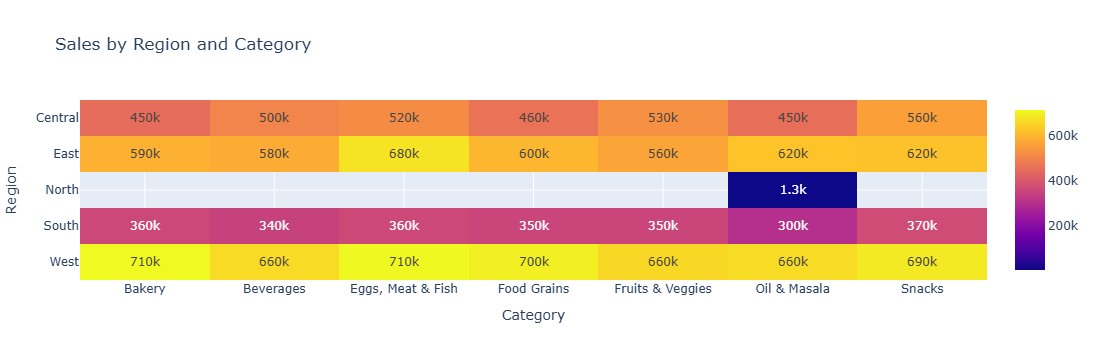

In [73]:
#Category × Region -Which categories perform strongly in each region?
#The heatmap lets us compare two dimensions at the same time: region and category."
#That sounds much more analytical while the code is actually quite simple.

category_region = (
    df.groupby(["Region", "Category"])["Sales"]
    .sum()
    .reset_index()
)

heatmap_data = category_region.pivot(
    index="Region",
    columns="Category",
    values="Sales"
)

fig = px.imshow(
    heatmap_data,
    text_auto=".2s",
    aspect="auto",
    title="Sales by Region and Category"
)

fig.show()

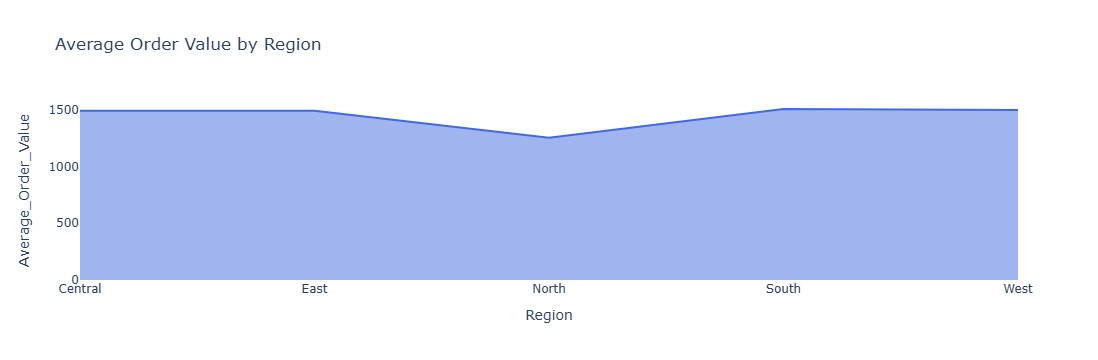

In [85]:
#Average Order Sales by Region-Which regions have higher-value orders on average?
fig = px.area(
    average_order,
    x="Region",
    y="Average_Order_Value",
    title="Average Order Value by Region",
)

fig.update_traces(line_color="royalblue")
fig.update_layout(plot_bgcolor="white")
fig.show()

In [119]:
correlation = df["Discount"].corr(df["Profit"])
print("Correlation between Discount and Profit:", correlation)
print(df[["Discount", "Profit"]].corr())

Correlation between Discount and Profit: 1.7476233317140002e-05
          Discount    Profit
Discount  1.000000  0.000017
Profit    0.000017  1.000000


In [ ]:
#The correlation between Discount and Profit is extremely close to zero (0.000017), indicating that there is no meaningful
#linear relationship between the two variables. The analysis shows the relationship between discount and profit. 
#Correlation does not prove that discount directly causes changes in profit.
#This means that increasing or decreasing the discount does not consistently impact profit in this dataset.
#The analysis suggests that higher discounts may be associated with lower profit. This could help management review discounting strategies.

In [ ]:
#Preapre ML Data
# -----------------------------
# 1. Convert Order Date column
# -----------------------------
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# -----------------------------
# 2. Create Year and Month
# -----------------------------
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

# -----------------------------
# 3. Prepare ML Features
# -----------------------------
features = [
    "Discount",
    "Category",
    "Sub Category",
    "Region",
    "Year",
    "Month"
]

X = df[features]
y = df["Sales"]


In [125]:
X = pd.get_dummies(
    X,
    columns=["Category", "Sub Category", "Region"],
    drop_first=True
)

In [127]:
#Split the data- We used 80% of the data to train the models and 20% to test how well they perform on unseen data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [129]:
#Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [131]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [133]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [135]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(name, actual, predicted):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "R2": r2_score(actual, predicted)
    }

results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    ),
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
])

results

,Model,MAE,RMSE,R2
0,Linear Regression,497.763060,576.491029,-0.007657
1,Decision Tree,671.549191,830.111071,-1.089296
2,Random Forest,524.599133,618.716180,-0.160674


In [ ]:
#The tested models had limited predictive performance with the available variables. 
#Linear Regression had the lowest MAE and RMSE among the three models, but its R² was approximately zero, 
#indicating that the available features were not sufficient for strong Sales prediction.

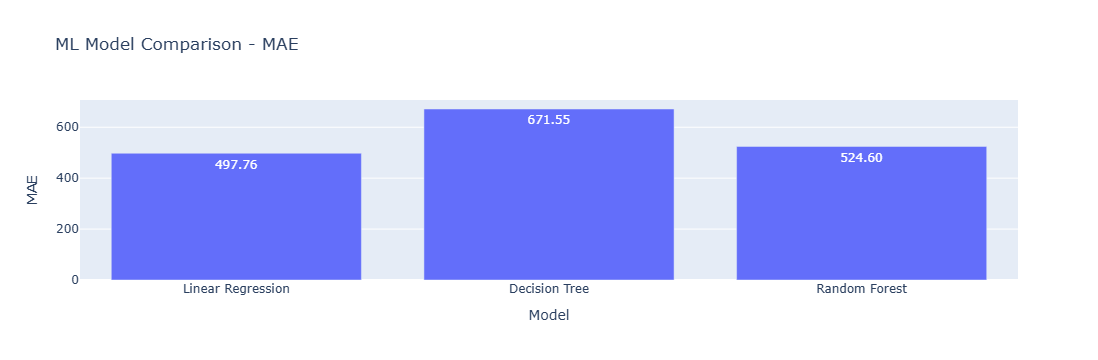

In [137]:
#ML section
fig = px.bar(
    results,
    x="Model",
    y="MAE",
    title="ML Model Comparison - MAE",
    text_auto=".2f"
)

fig.show()

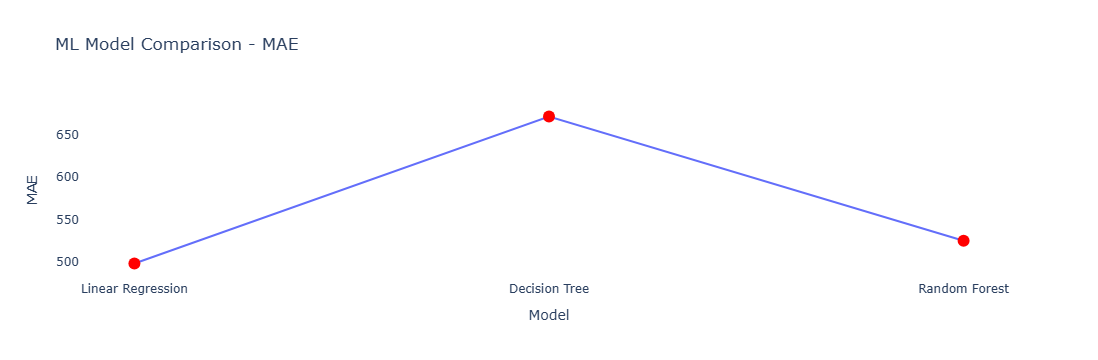

In [139]:
fig = px.line(
    results,
    x="Model",
    y="MAE",
    markers=True,
    title="ML Model Comparison - MAE"
)

fig.update_traces(marker=dict(size=12, color="red"))
fig.update_layout(plot_bgcolor="white")
fig.show()

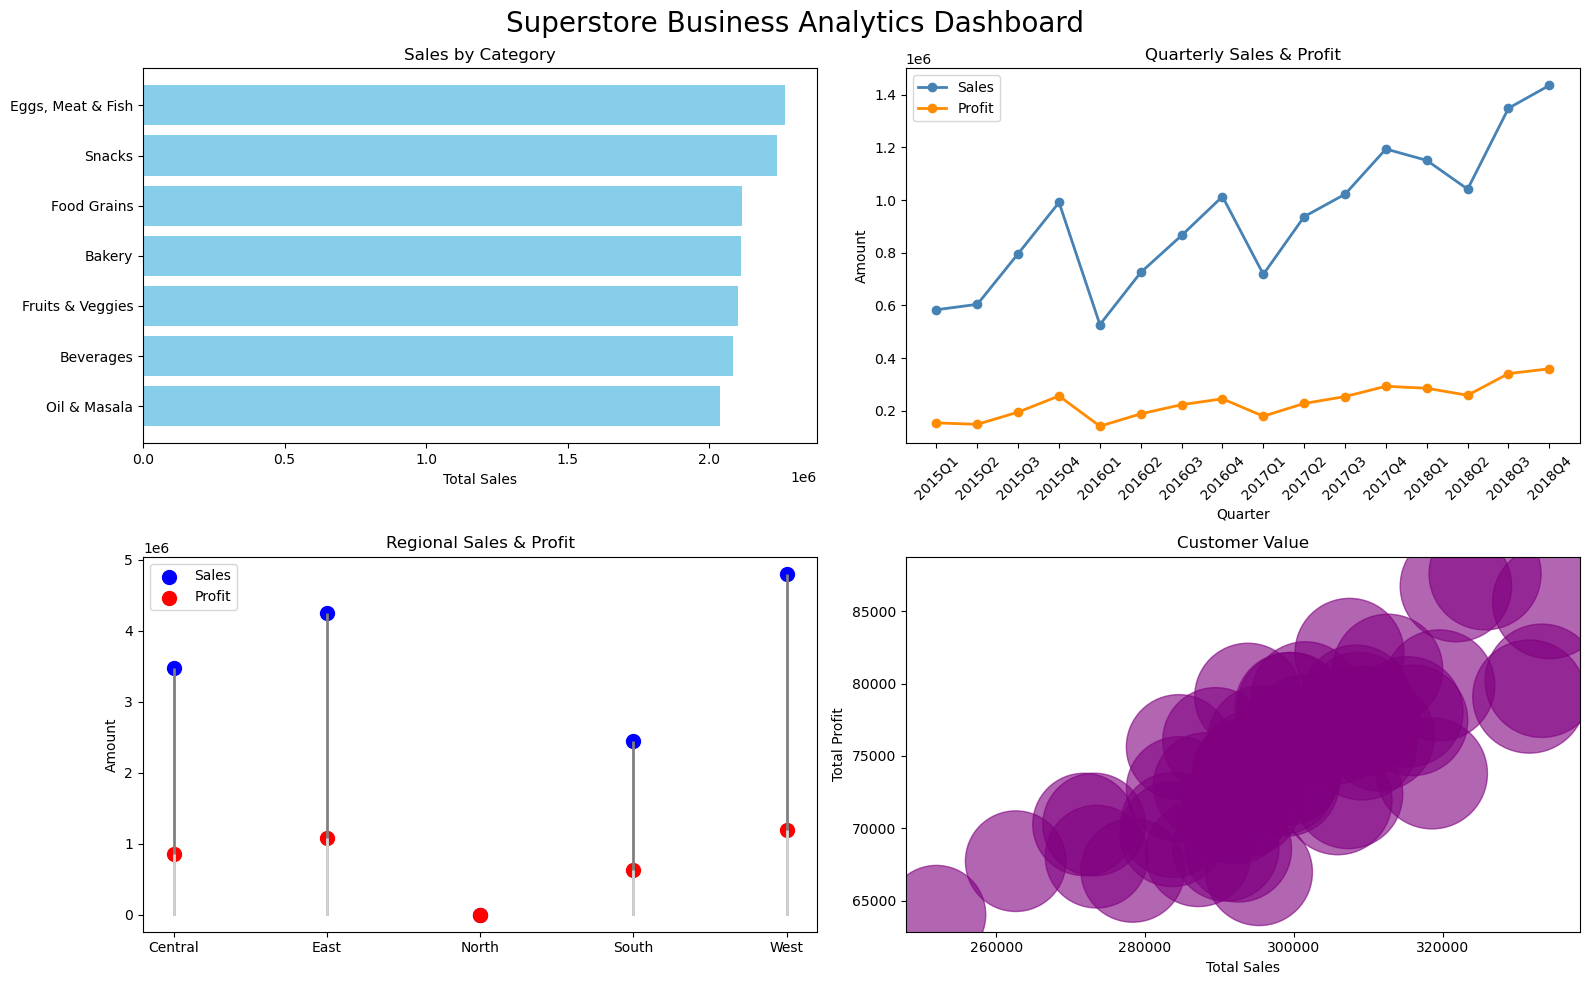

In [155]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure Order Date is in date format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

# ==========================================
# 1. PREPARE DATA
# ==========================================

# Sales by Category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Quarterly Sales and Profit (cleaner than monthly)
quarterly_data = (
    df.groupby(df["Order Date"].dt.to_period("Q"))
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

# Regional Sales and Profit
region_data = (
    df.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

# Customer Sales and Profit
customer_data = (
    df.groupby("Customer Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

# ==========================================
# 2. CREATE UPDATED DASHBOARD
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Superstore Business Analytics Dashboard", fontsize=20)

# ==========================================
# CHART 1 — CATEGORY SALES (Horizontal Bar)
# ==========================================

axes[0, 0].barh(
    category_sales.index,
    category_sales.values,
    color="skyblue"
)

axes[0, 0].set_title("Sales by Category")
axes[0, 0].set_xlabel("Total Sales")
axes[0, 0].invert_yaxis()

# ==========================================
# CHART 2 — QUARTERLY SALES & PROFIT (Clean Line Chart)
# ==========================================

quarters = quarterly_data.index.astype(str)

axes[0, 1].plot(
    quarters,
    quarterly_data["Sales"],
    marker="o",
    linewidth=2,
    label="Sales",
    color="steelblue"
)

axes[0, 1].plot(
    quarters,
    quarterly_data["Profit"],
    marker="o",
    linewidth=2,
    label="Profit",
    color="darkorange"
)

axes[0, 1].set_title("Quarterly Sales & Profit")
axes[0, 1].set_xlabel("Quarter")
axes[0, 1].set_ylabel("Amount")
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=45)

# ==========================================
# CHART 3 — REGIONAL PERFORMANCE (Lollipop Chart)
# ==========================================

x = range(len(region_data))

axes[1, 0].vlines(x, 0, region_data["Sales"], color="gray", linewidth=2)
axes[1, 0].scatter(x, region_data["Sales"], color="blue", s=100, label="Sales")

axes[1, 0].vlines(x, 0, region_data["Profit"], color="lightgray", linewidth=2)
axes[1, 0].scatter(x, region_data["Profit"], color="red", s=100, label="Profit")

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(region_data.index)
axes[1, 0].set_title("Regional Sales & Profit")
axes[1, 0].set_ylabel("Amount")
axes[1, 0].legend()

# ==========================================
# CHART 4 — CUSTOMER VALUE (Bubble Chart)
# ==========================================

axes[1, 1].scatter(
    customer_data["Sales"],
    customer_data["Profit"],
    s=customer_data["Sales"] / 50,
    alpha=0.6,
    color="purple"
)

axes[1, 1].set_title("Customer Value")
axes[1, 1].set_xlabel("Total Sales")
axes[1, 1].set_ylabel("Total Profit")

# ==========================================
# FINAL FORMATTING
# ==========================================

plt.tight_layout()
plt.show()


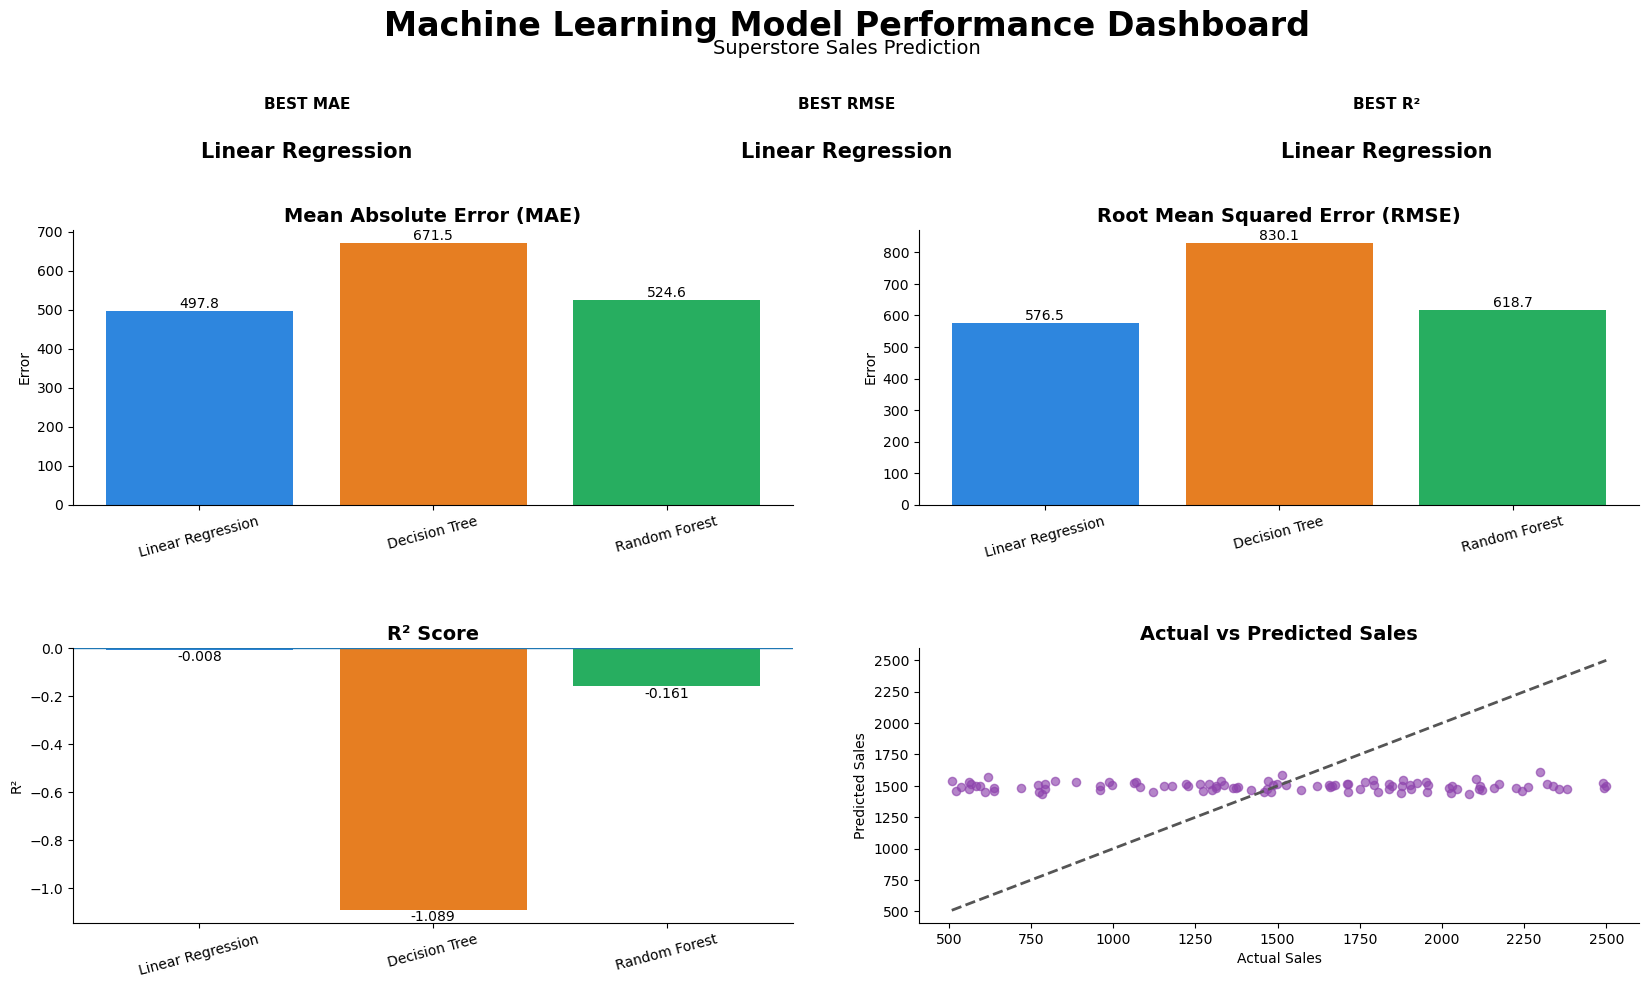


MODEL PERFORMANCE SUMMARY

Lowest MAE  : Linear Regression
Lowest RMSE : Linear Regression
Highest R²  : Linear Regression

Model Results:
            Model     MAE    RMSE     R2
Linear Regression 497.763 576.491 -0.008
    Decision Tree 671.549 830.111 -1.089
    Random Forest 524.599 618.716 -0.161

Key Insight:
Linear Regression produced the lowest prediction errors among the three tested models.
However, all R² values are negative, indicating that the models have limited predictive power for Sales with the current variables.


In [163]:
# ==========================================
# PROFESSIONAL ML DASHBOARD
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# MODEL COLORS
# ------------------------------------------

model_colors = {
    "Linear Regression": "#2E86DE",
    "Decision Tree": "#E67E22",
    "Random Forest": "#27AE60"
}


# ------------------------------------------
# FIND BEST MODELS
# ------------------------------------------

best_mae_model = results.loc[
    results["MAE"].idxmin(), "Model"
]

best_rmse_model = results.loc[
    results["RMSE"].idxmin(), "Model"
]

best_r2_model = results.loc[
    results["R2"].idxmax(), "Model"
]


# ==========================================
# CREATE DASHBOARD
# ==========================================

fig = plt.figure(figsize=(18, 11))

fig.suptitle(
    "Machine Learning Model Performance Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.93,
    "Superstore Sales Prediction",
    ha="center",
    fontsize=14
)


# ==========================================
# KPI CARDS
# ==========================================

fig.text(
    0.20, 0.88,
    "BEST MAE",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.20, 0.835,
    best_mae_model,
    ha="center",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.50, 0.88,
    "BEST RMSE",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.50, 0.835,
    best_rmse_model,
    ha="center",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.80, 0.88,
    "BEST R²",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.80, 0.835,
    best_r2_model,
    ha="center",
    fontsize=15,
    fontweight="bold"
)


# ==========================================
# CHART 1 - MAE
# ==========================================

ax1 = fig.add_axes([0.07, 0.52, 0.40, 0.25])

colors = [
    model_colors[model]
    for model in results["Model"]
]

bars = ax1.bar(
    results["Model"],
    results["MAE"],
    color=colors
)

ax1.set_title(
    "Mean Absolute Error (MAE)",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel("Error")

ax1.tick_params(axis="x", rotation=15)

for bar, value in zip(bars, results["MAE"]):

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


# ==========================================
# CHART 2 - RMSE
# ==========================================

ax2 = fig.add_axes([0.54, 0.52, 0.40, 0.25])

bars = ax2.bar(
    results["Model"],
    results["RMSE"],
    color=colors
)

ax2.set_title(
    "Root Mean Squared Error (RMSE)",
    fontsize=14,
    fontweight="bold"
)

ax2.set_ylabel("Error")

ax2.tick_params(axis="x", rotation=15)

for bar, value in zip(bars, results["RMSE"]):

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)


# ==========================================
# CHART 3 - R²
# ==========================================

ax3 = fig.add_axes([0.07, 0.14, 0.40, 0.25])

bars = ax3.bar(
    results["Model"],
    results["R2"],
    color=colors
)

ax3.axhline(
    0,
    linewidth=1
)

ax3.set_title(
    "R² Score",
    fontsize=14,
    fontweight="bold"
)

ax3.set_ylabel("R²")

ax3.tick_params(axis="x", rotation=15)

for bar, value in zip(bars, results["R2"]):

    if value >= 0:
        y_position = value
        vertical_alignment = "bottom"
    else:
        y_position = value
        vertical_alignment = "top"

    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{value:.3f}",
        ha="center",
        va=vertical_alignment,
        fontsize=10
    )

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)


# ==========================================
# CHART 4 - ACTUAL VS PREDICTED
# ==========================================

ax4 = fig.add_axes([0.54, 0.14, 0.40, 0.25])

# Use first 100 observations
actual = np.array(y_test)[:100]
predicted = np.array(linear_pred)[:100]

ax4.scatter(
    actual,
    predicted,
    alpha=0.65,
    s=35,
    color="#8E44AD"
)

# Perfect prediction line
minimum = min(
    actual.min(),
    predicted.min()
)

maximum = max(
    actual.max(),
    predicted.max()
)

ax4.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2,
    color="#555555"
)

ax4.set_title(
    "Actual vs Predicted Sales",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Actual Sales")
ax4.set_ylabel("Predicted Sales")

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)


# ==========================================
# FINAL DISPLAY
# ==========================================

plt.show()


# ==========================================
# PRINT SIMPLE INTERPRETATION
# ==========================================

print("\n" + "=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(
    f"\nLowest MAE  : {best_mae_model}"
)

print(
    f"Lowest RMSE : {best_rmse_model}"
)

print(
    f"Highest R²  : {best_r2_model}"
)

print("\nModel Results:")
print(
    results.round(3).to_string(index=False)
)

print("\nKey Insight:")
print(
    "Linear Regression produced the lowest prediction errors "
    "among the three tested models."
)

print(
    "However, all R² values are negative, indicating that "
    "the models have limited predictive power for Sales "
    "with the current variables."
)

In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html
import dash_bootstrap_components as dbc

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(r"C:\Users\rajes\OneDrive\Documents\Supermart_Project\Supermart Grocery Sales - Retail Analytics Dataset.csv")

# FIX: Mixed date formats
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df = df.dropna(subset=["Order Date"])

# ============================================================
# ANALYTICS DATA
# ============================================================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

quarterly_data = (
    df.groupby(df["Order Date"].dt.to_period("Q"))
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
)
quarterly_data.index = quarterly_data.index.astype(str)

region_data = df.groupby("Region").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))

customer_data = df.groupby("Customer Name").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))

# ============================================================
# MACHINE LEARNING
# ============================================================

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

features = ["Discount", "Category", "Sub Category", "Region", "Year", "Month"]
X = pd.get_dummies(df[features], drop_first=True).fillna(0)
y = df["Sales"].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression().fit(X_train, y_train)
tree_model = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

def evaluate(name, actual, pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "R2": r2_score(actual, pred)
    }

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, linear_pred),
    evaluate("Decision Tree", y_test, tree_pred),
    evaluate("Random Forest", y_test, rf_pred)
])

# ============================================================
# DASH APP
# ============================================================

app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

app.layout = dbc.Container([
    html.H1("Supermart Retail Analytics Dashboard", className="text-center mt-4 mb-4"),

    dcc.Tabs([
        dcc.Tab(label="Category Sales", children=[
            dcc.Graph(
                figure=px.bar(
                    category_sales,
                    orientation="h",
                    title="Sales by Category",
                    labels={"value": "Sales", "index": "Category"},
                    color=category_sales.values
                )
            )
        ]),

        dcc.Tab(label="Quarterly Performance", children=[
            dcc.Graph(
                figure=go.Figure([
                    go.Scatter(
                        x=quarterly_data.index,
                        y=quarterly_data["Sales"],
                        mode="lines+markers",
                        name="Sales",
                        line=dict(color="blue")
                    ),
                    go.Scatter(
                        x=quarterly_data.index,
                        y=quarterly_data["Profit"],
                        mode="lines+markers",
                        name="Profit",
                        line=dict(color="orange")
                    )
                ]).update_layout(title="Quarterly Sales & Profit")
            )
        ]),

        dcc.Tab(label="Regional Performance", children=[
            dcc.Graph(
                figure=px.scatter(
                    region_data,
                    x="Sales",
                    y="Profit",
                    size="Sales",
                    color=region_data.index,
                    title="Regional Sales & Profit",
                    hover_name=region_data.index
                )
            )
        ]),

        dcc.Tab(label="Customer Value", children=[
            dcc.Graph(
                figure=px.scatter(
                    customer_data,
                    x="Sales",
                    y="Profit",
                    size="Sales",
                    hover_name=customer_data.index,
                    title="Customer Value Matrix"
                )
            )
        ]),

        dcc.Tab(label="ML Model Comparison", children=[
            dcc.Graph(
                figure=px.bar(
                    results,
                    x="Model",
                    y="MAE",
                    title="Model Comparison - MAE",
                    text_auto=".2f",
                    color="MAE"
                )
            ),
            dcc.Graph(
                figure=px.bar(
                    results,
                    x="Model",
                    y="RMSE",
                    title="Model Comparison - RMSE",
                    text_auto=".2f",
                    color="RMSE"
                )
            ),
            dcc.Graph(
                figure=px.bar(
                    results,
                    x="Model",
                    y="R2",
                    title="Model Comparison - R²",
                    text_auto=".3f",
                    color="R2"
                )
            )
        ]),

        dcc.Tab(label="Actual vs Predicted", children=[
            dcc.Graph(
                figure=px.scatter(
                    x=y_test[:100],
                    y=linear_pred[:100],
                    labels={"x": "Actual Sales", "y": "Predicted Sales"},
                    title="Actual vs Predicted (Linear Regression)",
                    trendline="ols"
                )
            )
        ])
    ])
], fluid=True)

# ⭐ RUN DASH (TERMINAL ONLY)
if __name__ == "__main__":
    app.run(debug=True, port=8055)

# Dash Section: Building the Dashboard Step by Step

The dashboard will contain:

- **Four KPIs:** Total Sales, Total Profit, Total Orders and Profit Margin
- **Four Plotly charts** based on chart ideas already used in the analysis
- **One Year dropdown**
- **One callback** that updates all four KPIs and all four charts


## 1. Import the libraries and Create a Year column


In [ ]:
import pandas as pd
import plotly.express as px
from dash import Dash, Input, Output, dcc, html
from IPython.display import display


df_dash = pd.read_csv("../data/Supermart Grocery Sales.csv")


# The source contains dates written with / and - separators.
date_text = df_dash["Order Date"].astype("string").str.strip()
slash_dates = date_text.str.contains("/", regex=False)

parsed_dates = pd.Series(pd.NaT, index=df_dash.index, dtype="datetime64[ns]")
parsed_dates.loc[slash_dates] = pd.to_datetime(
    date_text.loc[slash_dates],
    format="%m/%d/%Y",
    errors="coerce"
)
parsed_dates.loc[~slash_dates] = pd.to_datetime(
    date_text.loc[~slash_dates],
    format="%d-%m-%Y",
    errors="coerce"
)

df_dash["Order Date"] = parsed_dates
df_dash["Year"] = df_dash["Order Date"].dt.year

assert df_dash["Order Date"].notna().all(), "Some dates could not be converted."

print(f"Rows loaded: {len(df_dash):,}")
print(
    f"Date range: {df_dash['Order Date'].min():%d %b %Y} "
    f"to {df_dash['Order Date'].max():%d %b %Y}"
)
display(df_dash.head(3))


Rows loaded: 9,994
Date range: 02 Jan 2015 to 30 Dec 2018


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Year
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,2017
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,2017
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,2017


## 2. Stage 1: Create the first Dash layout

A Dash application needs two things to begin:

1. `Dash()` creates the application.
2. `app.layout` describes what appears on the page.

Our first layout contains only the dashboard heading. Run the cell and the first version of the webpage appears immediately.


In [ ]:
# put the colors and styles in a dictionary so that they can be reused across the dashboard
COLORS = {
    "navy": "#102A43",
    "blue": "#2563EB",
    "teal": "#0F9D8A",
    "gold": "#E59A2F",
    "purple": "#7C5CE7",
    "text": "#243B53",
    "muted": "#6B7C93",
    "border": "#E2E8F0",
    "background": "#F5F7FA",
    "white": "#FFFFFF"
}

PAGE_STYLE = {
    "backgroundColor": COLORS["background"],
    "minHeight": "100vh",
    "padding": "28px 22px 44px",
    "fontFamily": "Segoe UI, Arial, sans-serif",
    "color": COLORS["text"]
}

CONTENT_STYLE = {
    "maxWidth": "1380px",
    "margin": "0 auto"
}

HEADER_STYLE = {
    "background": "linear-gradient(125deg, #102A43 0%, #1D4E73 62%, #2563EB 100%)",
    "color": "white",
    "padding": "30px 32px",
    "borderRadius": "20px",
    "boxShadow": "0 16px 34px rgba(16, 42, 67, 0.18)",
    "marginBottom": "18px"
}


def dashboard_header():
    first_year = int(df_dash["Year"].min())
    last_year = int(df_dash["Year"].max())

    return html.Div(
        [
            html.P(
                "RETAIL PERFORMANCE",
                style={
                    "margin": "0 0 8px",
                    "fontSize": "12px",
                    "fontWeight": "700",
                    "letterSpacing": "2px",
                    "color": "#BFDBFE"
                }
            ),
            html.H1(
                "Supermart Sales Dashboard",
                style={
                    "margin": "0",
                    "fontSize": "34px",
                    "fontWeight": "700"
                }
            ),
            html.P(
                "A clear view of sales, profit and customer performance",
                style={
                    "margin": "9px 0 18px",
                    "fontSize": "16px",
                    "color": "#DCEBFA"
                }
            ),
            html.Span(
                f"{first_year}–{last_year}",
                style={
                    "display": "inline-block",
                    "padding": "7px 12px",
                    "border": "1px solid rgba(255,255,255,0.28)",
                    "borderRadius": "999px",
                    "fontSize": "13px",
                    "backgroundColor": "rgba(255,255,255,0.10)"
                }
            )
        ],
        style=HEADER_STYLE
    )


def dashboard_page(children):
    # Keep every stage centred and consistently spaced.
    return html.Div(
        html.Div(children, style=CONTENT_STYLE),
        style=PAGE_STYLE
    )


# Create the app and give it its first layout.
stage_1 = Dash("dash_stage_1")
stage_1.layout = dashboard_page([dashboard_header()])

stage_1.run(jupyter_mode="inline", port=8061, debug=False)


## 3. Stage 2: Add the Year dropdown

`dcc.Dropdown()` adds a control to the layout.


In [34]:
# Create one option for all years and one option for each year in the data.
year_options = ["All Years"] + sorted(
    df_dash["Year"].dropna().astype(int).unique().tolist()
)

FILTER_STYLE = {
    "display": "flex",
    "alignItems": "center",
    "justifyContent": "space-between",
    "gap": "18px",
    "flexWrap": "wrap",
    "backgroundColor": COLORS["white"],
    "padding": "16px 18px",
    "border": f"1px solid {COLORS['border']}",
    "borderRadius": "14px",
    "boxShadow": "0 5px 16px rgba(16, 42, 67, 0.06)",
    "marginBottom": "18px"
}


def year_dropdown(component_id):
    return html.Div(
        [
            html.Div(
                [
                    html.P(
                        "Dashboard filter",
                        style={
                            "margin": "0",
                            "fontWeight": "700",
                            "color": COLORS["navy"]
                        }
                    ),
                    html.P(
                        "Choose a year to update every result",
                        style={
                            "margin": "4px 0 0",
                            "fontSize": "13px",
                            "color": COLORS["muted"]
                        }
                    )
                ]
            ),
            html.Div(
                [
                    html.Label(
                        "YEAR",
                        style={
                            "display": "block",
                            "marginBottom": "6px",
                            "fontSize": "11px",
                            "fontWeight": "700",
                            "letterSpacing": "1px",
                            "color": COLORS["muted"]
                        }
                    ),
                    dcc.Dropdown(
                        id=component_id,
                        options=year_options,
                        value="All Years",
                        clearable=False
                    )
                ],
                style={"width": "260px", "maxWidth": "100%"}
            )
        ],
        style=FILTER_STYLE
    )


stage_2 = Dash("dash_stage_2")
stage_2.layout = dashboard_page(
    [
        dashboard_header(),
        year_dropdown("stage-2-year")
    ]
)

stage_2.run(jupyter_mode="inline", port=8062, debug=False)


## 4. Calculate the four KPIs

A **KPI** is an important summary number. The function below calculates:

- Total Sales
- Total Profit
- Total Orders
- Profit Margin

Profit margin is calculated as:

We first display the answers as a small table. In the next stage, we place them inside dashboard cards.


In [24]:
def calculate_kpis(data):
    total_sales = data["Sales"].sum()
    total_profit = data["Profit"].sum()
    total_orders = data["Order ID"].nunique()
    profit_margin = total_profit / total_sales if total_sales else 0

    return total_sales, total_profit, total_orders, profit_margin


sales_value, profit_value, order_value, margin_value = calculate_kpis(df_dash)

kpi_check = pd.DataFrame({
    "KPI": ["Total Sales", "Total Profit", "Total Orders", "Profit Margin"],
    "Value": [
        f"{sales_value:,.0f}",
        f"{profit_value:,.2f}",
        f"{order_value:,}",
        f"{margin_value:.2%}"
    ]
})

display(kpi_check)


,KPI,Value
0,Total Sales,"14,956,982"
1,Total Profit,"3,747,121.20"
2,Total Orders,"9,994"
3,Profit Margin,25.05%


## 5. Stage 3: Add the four KPI cards

Each KPI card is an `html.Div()` containing a label and a value. The cards currently show totals for all years. The callback will make them change later.


In [45]:
KPI_ROW_STYLE = {
    "display": "grid",
    "gridTemplateColumns": "repeat(auto-fit, minmax(210px, 1fr))",
    "gap": "14px",
    "marginBottom": "24px"
}


def kpi_card(title, value, note, accent, component_id=None):
    # The ID is added only when the callback needs to update the value.
    value_settings = {
        "style": {
            "margin": "8px 0 5px",
            "fontSize": "28px",
            "fontWeight": "700",
            "color": COLORS["navy"]
        }
    }
    if component_id is not None:
        value_settings["id"] = component_id

    return html.Div(
        [
            html.P(
                title.upper(),
                style={
                    "margin": "0",
                    "fontSize": "11px",
                    "fontWeight": "700",
                    "letterSpacing": "1px",
                    "color": COLORS["muted"]
                }
            ),
            html.H2(value, **value_settings),
            html.P(
                note,
                style={
                    "margin": "0",
                    "fontSize": "12px",
                    "color": COLORS["muted"]
                }
            )
        ],
        style={
            "backgroundColor": COLORS["white"],
            "padding": "18px 19px",
            "border": f"1px solid {COLORS['border']}",
            "borderTop": f"4px solid {accent}",
            "borderRadius": "14px",
            "boxShadow": "0 6px 18px rgba(16, 42, 67, 0.07)"
        }
    )


def kpi_row(sales, profit, orders, margin, use_ids=False):
    return html.Div(
        [
            kpi_card(
                "Total Sales", f"{sales:,.0f}", "Across the selected period",
                COLORS["blue"], "total-sales" if use_ids else None
            ),
            kpi_card(
                "Total Profit", f"{profit:,.2f}", "Profit received after costs",
                COLORS["teal"], "total-profit" if use_ids else None
            ),
            kpi_card(
                "Total Orders", f"{orders:,}", "Customer orders",
                COLORS["purple"], "total-orders" if use_ids else None
            ),
            kpi_card(
                "Profit Margin", f"{margin:.2%}", "Profit as a share of sales",
                COLORS["gold"], "profit-margin" if use_ids else None
            )
        ],
        style=KPI_ROW_STYLE
    )


stage_3 = Dash("dash_stage_3")
stage_3.layout = dashboard_page(
    [
        dashboard_header(),
        year_dropdown("stage-3-year"),
        kpi_row(sales_value, profit_value, order_value, margin_value)
    ]
)

stage_3.run(jupyter_mode="inline", port=8063, debug=False)


## 6. Prepare the first two Plotly charts


1. Sales and Profit by Category
2. Regional Sales and Profit

Each function accepts a DataFrame and returns a Plotly figure. Both figures appear below when the cell runs.


In [46]:
def polish_figure(figure):
    # Give every Plotly chart the same appearance.
    figure.update_layout(
        height=390,
        margin=dict(l=35, r=25, t=65, b=40),
        paper_bgcolor="white",
        plot_bgcolor="white",
        font=dict(family="Segoe UI, Arial, sans-serif", color=COLORS["text"]),
        title=dict(x=0.02, xanchor="left", font=dict(size=18, color=COLORS["navy"])),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
            title_text=""
        )
    )
    figure.update_xaxes(showgrid=False, zeroline=False)
    figure.update_yaxes(gridcolor="#EEF2F7", zeroline=False)
    return figure


def make_category_chart(data):
    category_data = (
        data.groupby("Category", as_index=False)
        .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    )

    figure = px.bar(
        category_data,
        x="Category",
        y=["Sales", "Profit"],
        barmode="group",
        title="Sales and Profit by Category",
        labels={"value": "Amount", "variable": "Measure"},
        color_discrete_sequence=[COLORS["blue"], COLORS["teal"]]
    )
    return polish_figure(figure)


def make_region_chart(data):
    region_data = (
        data.groupby("Region", as_index=False)
        .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    )

    figure = px.treemap(
        region_data,
        path=["Region"],
        values="Sales",
        color="Profit",
        color_continuous_scale=["#DDEAFE", "#5B9CF6", "#173B68"],
        title="Regional Sales and Profit"
    )
    figure.update_traces(marker_line_width=2, marker_line_color="white")
    return polish_figure(figure)


category_figure = make_category_chart(df_dash)
region_figure = make_region_chart(df_dash)

category_figure.show()
region_figure.show()


## 7. Stage 4: Place the first two charts in the layout

`dcc.Graph()` is the Dash component that displays a Plotly figure. The two figures are placed inside a two-column grid.


In [47]:
CHART_GRID_STYLE = {
    "display": "grid",
    "gridTemplateColumns": "repeat(auto-fit, minmax(min(100%, 520px), 1fr))",
    "gap": "16px"
}


def section_heading(title, subtitle):
    return html.Div(
        [
            html.H2(
                title,
                style={"margin": "0", "fontSize": "21px", "color": COLORS["navy"]}
            ),
            html.P(
                subtitle,
                style={"margin": "5px 0 0", "fontSize": "13px", "color": COLORS["muted"]}
            )
        ],
        style={"margin": "4px 0 12px"}
    )


def chart_card(figure=None, component_id=None):
    graph_settings = {
        "config": {"displayModeBar": False, "responsive": True}
    }
    if figure is not None:
        graph_settings["figure"] = figure
    if component_id is not None:
        graph_settings["id"] = component_id

    return html.Div(
        dcc.Graph(**graph_settings),
        style={
            "backgroundColor": COLORS["white"],
            "padding": "6px",
            "border": f"1px solid {COLORS['border']}",
            "borderRadius": "16px",
            "boxShadow": "0 7px 20px rgba(16, 42, 67, 0.07)",
            "overflow": "hidden"
        }
    )


stage_4 = Dash("dash_stage_4")
stage_4.layout = dashboard_page(
    [
        dashboard_header(),
        year_dropdown("stage-4-year"),
        kpi_row(sales_value, profit_value, order_value, margin_value),
        section_heading(
            "Performance overview",
            "Compare product categories and regional contribution"
        ),
        html.Div(
            [
                chart_card(category_figure),
                chart_card(region_figure)
            ],
            style=CHART_GRID_STYLE
        )
    ]
)

stage_4.run(jupyter_mode="inline", port=8064, debug=False)


## 8. Prepare the remaining two Plotly charts


3. Customer Value
4. Sales by Region and Category

Again, the cell displays both figures before we add them to Dash.


In [48]:
def make_customer_chart(data):
    customer_data = (
        data.groupby("Customer Name", as_index=False)
        .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    )

    figure = px.scatter(
        customer_data,
        x="Sales",
        y="Profit",
        size="Sales",
        color="Profit",
        hover_name="Customer Name",
        size_max=22,
        color_continuous_scale=["#DDEAFE", "#3B82F6", "#102A43"],
        title="Customer Value: Sales and Profit"
    )
    figure.update_traces(opacity=0.76, marker_line_width=0)
    return polish_figure(figure)


def make_heatmap_chart(data):
    category_region = (
        data.groupby(["Region", "Category"])["Sales"]
        .sum()
        .reset_index()
    )

    heatmap_data = category_region.pivot(
        index="Region",
        columns="Category",
        values="Sales"
    ).fillna(0)

    figure = px.imshow(
        heatmap_data,
        text_auto=".2s",
        aspect="auto",
        color_continuous_scale=["#EFF6FF", "#93C5FD", "#1D4ED8"],
        title="Sales by Region and Category",
        labels={"x": "Category", "y": "Region", "color": "Sales"}
    )
    return polish_figure(figure)


customer_figure = make_customer_chart(df_dash)
heatmap_figure = make_heatmap_chart(df_dash)

customer_figure.show()
heatmap_figure.show()


## 9. Stage 5: Complete the static layout

The dashboard now contains the heading, dropdown, four KPI cards and four charts. It is complete visually, but the dropdown still does not update anything.


In [49]:
stage_5 = Dash("dash_stage_5")
stage_5.layout = dashboard_page(
    [
        dashboard_header(),
        year_dropdown("stage-5-year"),
        kpi_row(sales_value, profit_value, order_value, margin_value),
        section_heading(
            "Performance overview",
            "Explore category, region and customer results"
        ),
        html.Div(
            [
                chart_card(category_figure),
                chart_card(region_figure),
                chart_card(customer_figure),
                chart_card(heatmap_figure)
            ],
            style=CHART_GRID_STYLE
        )
    ]
)

stage_5.run(jupyter_mode="inline", port=8065, debug=False)


## 11. Stage 6: Add the callback

A callback connects an **input** to one or more **outputs**.

In this dashboard:

- **Input:** the year selected in the dropdown
- **Outputs:** four KPI values and four Plotly figures

The callback follows four simple steps:

1. Receive the selected year.
2. Filter the DataFrame.
3. Recalculate the KPIs and figures.
4. Return the eight updated results to the layout.


In [51]:
# Create the finished application.
app = Dash("supermart_dashboard")
app.title = "Supermart Sales Dashboard"

app.layout = dashboard_page(
    [
        dashboard_header(),
        year_dropdown("year-filter"),
        kpi_row(
            sales_value,
            profit_value,
            order_value,
            margin_value,
            use_ids=True
        ),
        section_heading(
            "Performance overview",
            "Explore category, region and customer results"
        ),
        html.Div(
            [
                chart_card(category_figure, "category-chart"),
                chart_card(region_figure, "region-chart"),
                chart_card(customer_figure, "customer-chart"),
                chart_card(heatmap_figure, "heatmap-chart")
            ],
            style=CHART_GRID_STYLE
        )
    ]
)


@app.callback(
    Output("total-sales", "children"),
    Output("total-profit", "children"),
    Output("total-orders", "children"),
    Output("profit-margin", "children"),
    Output("category-chart", "figure"),
    Output("region-chart", "figure"),
    Output("customer-chart", "figure"),
    Output("heatmap-chart", "figure"),
    Input("year-filter", "value")
)
def update_dashboard(selected_year):
    # Step 1: Filter the rows.
    if selected_year == "All Years":
        filtered_data = df_dash.copy()
    else:
        filtered_data = df_dash[df_dash["Year"] == selected_year].copy()

    # Step 2: Recalculate the four KPIs.
    sales, profit, orders, margin = calculate_kpis(filtered_data)

    # Step 3: Rebuild the four figures.
    category_chart = make_category_chart(filtered_data)
    region_chart = make_region_chart(filtered_data)
    customer_chart = make_customer_chart(filtered_data)
    heatmap_chart = make_heatmap_chart(filtered_data)

    # Step 4: Return the eight outputs in the same order as above.
    return (
        f"{sales:,.0f}",
        f"{profit:,.2f}",
        f"{orders:,}",
        f"{margin:.2%}",
        category_chart,
        region_chart,
        customer_chart,
        heatmap_chart
    )


app.run(jupyter_mode="external", port=8066, debug=False)


Dash app running on http://127.0.0.1:8066/
